# Different short rate options

Monthly variants:
- 1M curve
- 1M RUONIA
- monthly mean key rate of the Bank of Russia

Daily variants:
- 1M curve from daily MOEX curve data
- daily RUONIA
- key rate on a specific day


## Data convention

The notebook keeps everything in the same unit for display: annualized percent.
For ACM-ready transformations you can convert any rate with `log1p(rate / 100) / 12` later.

For the key rate, the notebook first tries the official CBR history page and falls back to the local monthly table
in `data/key_rate_and_inflation.csv` if the network is unavailable.


In [290]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from run_acm_model import run_acm_model
from build_moex_curve import build_moex_curve
from ruonia import build_ruonia_monthly, load_ruonia_1m

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
OUTPUT_DIR = ROOT / 'output'
SURVEY_WIDE_PATH = DATA_DIR / 'cbr_key_rate_survey_by_year.csv'
SAMPLE_START = pd.Timestamp('2021-05-31')
SAMPLE_END = pd.Timestamp('2024-05-31')

START_DATE = pd.Timestamp('2014-01-31')
END_DATE = pd.Timestamp('2024-05-31')
FOCUS_DAY = pd.Timestamp('2024-05-31')

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


In [291]:
def annual_to_monthly_cc(rate_pct: pd.Series) -> pd.Series:
    return np.log1p(rate_pct / 100.0) / 12.0


def normalize_daily_series(series: pd.Series, start: pd.Timestamp, end: pd.Timestamp) -> pd.Series:
    daily_index = pd.date_range(start, end, freq='D')
    return series.sort_index().reindex(daily_index).ffill()


def summarize_series(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []
    for col in columns:
        s = frame[col].dropna()
        rows.append(
            {
                'series': col,
                'start': None if s.empty else s.index.min(),
                'end': None if s.empty else s.index.max(),
                'n_obs': int(s.shape[0]),
                'mean': float(s.mean()) if not s.empty else np.nan,
                'std': float(s.std(ddof=1)) if s.shape[0] > 1 else np.nan,
                'latest': float(s.iloc[-1]) if not s.empty else np.nan,
            }
        )
    return pd.DataFrame(rows)


def build_comparison_frame(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    out = frame[columns].copy()
    out['curve_minus_key_rate'] = out[columns[0]] - out[columns[-1]]
    out['ruonia_minus_key_rate'] = out[columns[1]] - out[columns[-1]]
    return out

def build_survey_anchor_from_wide(wide: pd.DataFrame) -> pd.Series:
    df = wide.copy()
    df['date'] = pd.to_datetime(df['date'])
    year_cols = [col for col in df.columns if col != 'date']
    year_cols = sorted(year_cols, key=lambda col: int(col))

    values = []
    for _, row in df.iterrows():
        survey_year = str(row['date'].year)
        value = row[survey_year] if survey_year in row.index else np.nan
        if pd.isna(value):
            future_cols = [col for col in year_cols if int(col) >= row['date'].year and pd.notna(row[col])]
            value = row[future_cols[0]] if future_cols else np.nan
        values.append(value)

    anchor = pd.Series(values, index=pd.DatetimeIndex(df['date']), name='survey_anchor_pct')
    return anchor.sort_index()

def load_survey_wide(path: str | Path = SURVEY_WIDE_PATH) -> pd.DataFrame:
    wide = pd.read_csv(path)
    wide['date'] = pd.to_datetime(wide['date'])
    year_cols = [col for col in wide.columns if col != 'date']
    wide[year_cols] = wide[year_cols].apply(pd.to_numeric, errors='coerce')
    return wide.sort_values('date').reset_index(drop=True)

def reindex_to_month_end(series: pd.Series, start: pd.Timestamp, end: pd.Timestamp, name: str | None = None) -> pd.Series:
    month_index = pd.date_range(start=start, end=end, freq='M')
    out = series.sort_index().reindex(month_index, method='ffill')
    if name is not None:
        out.name = name
    return out

def percent_to_monthly_log_rate(series: pd.Series, name: str | None = None) -> pd.Series:
    out = np.log1p(series.astype(float) / 100.0) / 12.0
    if name is not None:
        out.name = name
    return out

In [292]:
survey_wide = load_survey_wide()
survey_anchor_raw = build_survey_anchor_from_wide(survey_wide)
survey_anchor_monthly_pct = reindex_to_month_end(
    survey_anchor_raw,
    start=SAMPLE_START,
    end=SAMPLE_END,
    name='survey_anchor_pct',
)
print(survey_anchor_monthly_pct)
survey_anchor_monthly = percent_to_monthly_log_rate(
    survey_anchor_monthly_pct,
    name='survey_anchor_short_rate_cc',
)
survey_anchor_monthly = survey_anchor_monthly.loc[(survey_anchor_monthly.index >= SAMPLE_START) & (survey_anchor_monthly.index <= SAMPLE_END)]

2021-05-31    5.2350
2021-06-30    5.2350
2021-07-31    5.5100
2021-08-31    5.5100
2021-09-30    5.6600
2021-10-31    5.7000
2021-11-30    5.7000
2021-12-31    5.7700
2022-01-31    5.7700
2022-02-28    9.0750
2022-03-31   18.8550
2022-04-30   14.5000
2022-05-31   14.5000
2022-06-30   11.1100
2022-07-31   10.9750
2022-08-31   10.9750
2022-09-30   10.5000
2022-10-31   10.5800
2022-11-30   10.5800
2022-12-31   10.6000
2023-01-31   10.6000
2023-02-28    7.4700
2023-03-31    7.5000
2023-04-30    7.5000
2023-05-31    7.5000
2023-06-30    7.5000
2023-07-31    7.9000
2023-08-31    7.9000
2023-09-30    9.3000
2023-10-31    9.7650
2023-11-30    9.7650
2023-12-31    9.9450
2024-01-31    9.9450
2024-02-29   13.9000
2024-03-31   14.5027
2024-04-30   14.9100
2024-05-31   15.9000
Freq: ME, Name: survey_anchor_pct, dtype: float64


/var/folders/cj/d68fmsfj3jj2j09286d43rth0000gn/T/ipykernel_95921/4214791247.py:60: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_index = pd.date_range(start=start, end=end, freq='M')


In [ ]:
months = list(range(1, 121))
daily_curve, monthly_curve = build_moex_curve(
    dynamic_path=DATA_DIR / 'dynamic.csv',
    daily_output_path=OUTPUT_DIR / 'moex_curve_daily.csv',
    monthly_output_path=OUTPUT_DIR / 'moex_curve_monthly.csv',
    months=months,
)

ruonia_monthly = build_ruonia_monthly(load_ruonia_1m()).set_index('month_end')
ruonia_daily = pd.read_csv(DATA_DIR / 'ruonia.csv')
ruonia_daily['date'] = pd.to_datetime(ruonia_daily['DT'], format='%m/%d/%y')
ruonia_daily['ruonia_daily_pct'] = pd.to_numeric(ruonia_daily['ruo'], errors='coerce')
ruonia_daily = ruonia_daily.dropna(subset=['ruonia_daily_pct']).sort_values('date').set_index('date')['ruonia_daily_pct']
ruonia_daily = ruonia_daily.loc[START_DATE:END_DATE]

key_rate_daily = pd.read_csv('data/key_rate_daily.csv', parse_dates=['date'], index_col='date').loc[START_DATE:END_DATE]


curve_daily_1m = daily_curve.set_index('tradedate')['M001'].rename('curve_1m')
curve_daily_1m = curve_daily_1m.loc[START_DATE:END_DATE]
curve_monthly_1m = monthly_curve.set_index('month_end')['M001'].rename('curve_1m')
ruonia_monthly_1m = ruonia_monthly['ruonia_1m_pct'].rename('ruonia_1m')
key_rate_monthly_mean = key_rate_daily["key_rate"].resample('M').mean().rename('key_rate')

monthly_frame = pd.concat([curve_monthly_1m, ruonia_monthly_1m, key_rate_monthly_mean, survey_anchor_monthly_pct], axis=1)
monthly_frame = monthly_frame.loc[START_DATE:END_DATE].dropna(how='any')

/Users/codebuller/Desktop/term_rate/build_moex_curve.py:104: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  daily_curve.set_index("tradedate")[columns]
/var/folders/cj/d68fmsfj3jj2j09286d43rth0000gn/T/ipykernel_95921/357857651.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  key_rate_monthly_mean = key_rate_daily["key_rate"].resample('M').mean().rename('key_rate')


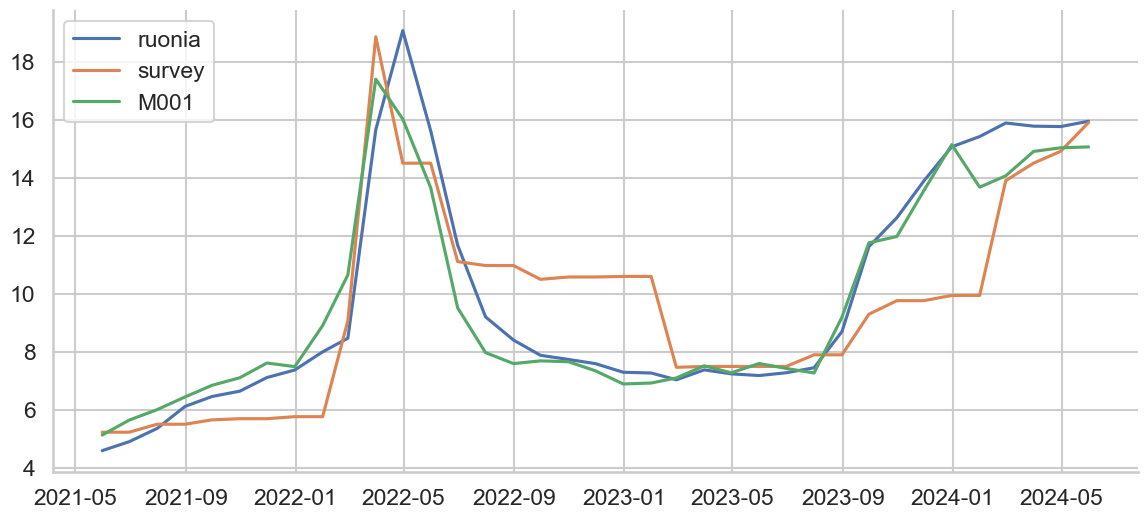

In [294]:
plt.figure()
plt.plot(ruonia_monthly_1m.loc[SAMPLE_START:SAMPLE_END], label='ruonia')
plt.plot(survey_anchor_monthly_pct, label='survey')
monthly_curve.index = monthly_curve["month_end"]
locm =  monthly_curve.loc[SAMPLE_START:SAMPLE_END]
plt.plot(locm["month_end"], locm["M001"], label='M001')
plt.legend() 

In [295]:
cb_tp_book_df = pd.read_csv('cb_tp/output/tp_10y_book_digitized_monthly.csv', index_col=['date'],parse_dates=['date'])
cb_tp_df = pd.read_csv('cb_tp/output/cb_tp_digitized_monthly.csv', index_col=['date'],parse_dates=['date'])
cb_tp_book = cb_tp_book_df['tp'].loc[START_DATE : END_DATE]
cb_tp = cb_tp_df[cb_tp_df['tenor_years']==10.0]['tp'].loc[START_DATE : END_DATE]

<Figure size 1000x600 with 0 Axes>

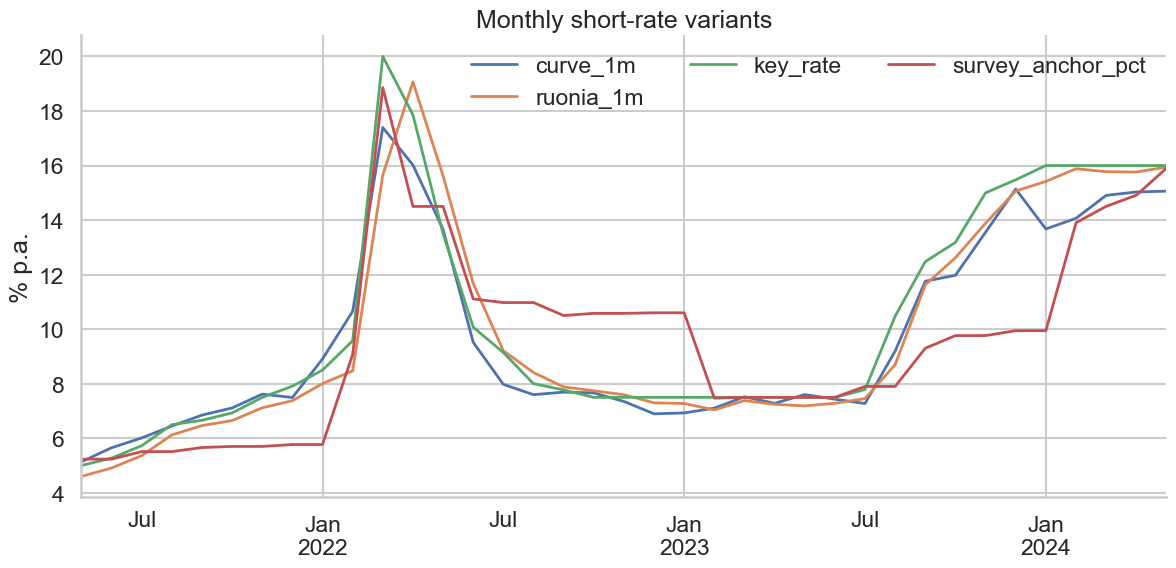

In [296]:
plt.figure(figsize=(10,6))
columns = ['curve_1m', 'ruonia_1m', 'key_rate', 'survey_anchor_pct']
monthly_frame[columns].plot( lw=2)
plt.title('Monthly short-rate variants')
plt.ylabel('% p.a.')
plt.legend(frameon=False, ncol=3)

In [297]:
selected_maturities = [3, 6, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120]
n_factors = 5


daily = {
    "curve_1m_daily": curve_daily_1m,
    "ruonia_daily": ruonia_daily,
    "key_rate_daily": key_rate_daily,
}

monthly = {
    "curve_1m": curve_monthly_1m,
    "ruonia_1m": ruonia_monthly_1m,
    "key_rate_month_mean": key_rate_monthly_mean,
}

survey = run_acm_model(
    date_from=SAMPLE_START,
    date_to=SAMPLE_END,
    n_factors=3,
    curve=monthly_curve, 
    short_rate_proxy=annual_to_monthly_cc(survey_anchor_monthly_pct)
)

daily_results = {}
monthly_results = {}
for name, proxy in daily.items():
    daily_results[name] = run_acm_model(
        selected_maturities=selected_maturities,
        date_from=START_DATE,
        date_to=END_DATE,
        short_rate_proxy=annual_to_monthly_cc(proxy),
        n_factors=n_factors,
        curve=daily_curve,
    )
for name, proxy in monthly.items():
    monthly_results[name] = run_acm_model(
        selected_maturities=selected_maturities,
        date_from=START_DATE,
        date_to=END_DATE,
        short_rate_proxy=annual_to_monthly_cc(proxy),
        n_factors=n_factors,
        curve=monthly_curve,
    )

/Users/codebuller/Desktop/term_rate/run_acm_model.py:297: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_source_curve = curve_m if curve_m is not None else raw_curve.resample("M").mean()
/Users/codebuller/Desktop/term_rate/run_acm_model.py:297: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_source_curve = curve_m if curve_m is not None else raw_curve.resample("M").mean()


ValueError: `selected_maturities` contains maturities that are not available in the curve: [120]

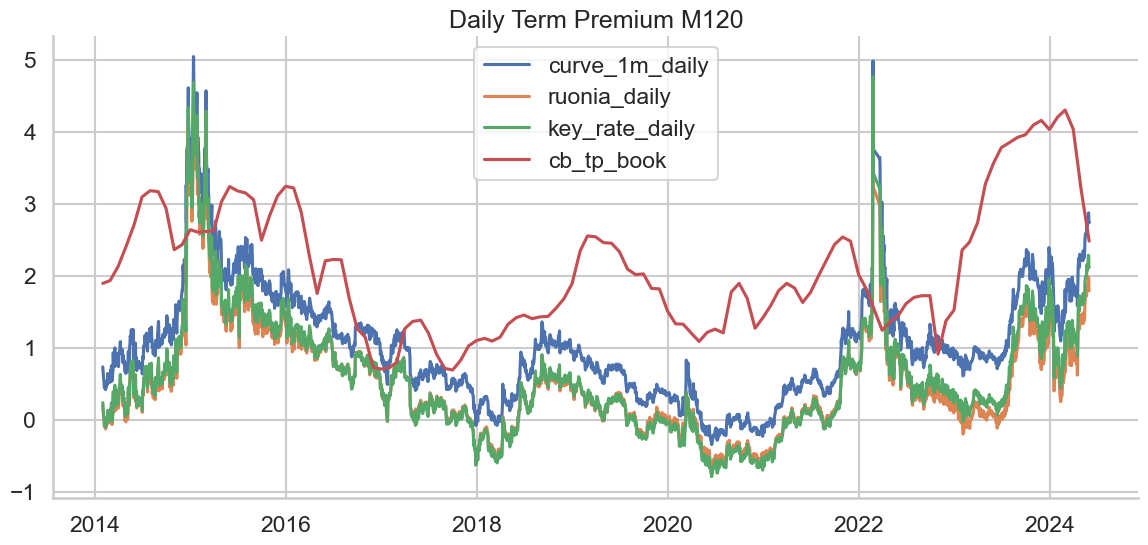

In [ ]:
plt.figure()
plt.title("Daily Term Premium M120")
for name, result in daily_results.items():
    index = result.term_premium_frame.date
    result.term_premium_frame.index = index
    plt.plot( result.term_premium_frame['tp_M120'] , label=name)
# plt.plot( cb_tp, label='cb_tp')
plt.plot( cb_tp_book, label='cb_tp_book')
plt.legend()
plt.show()

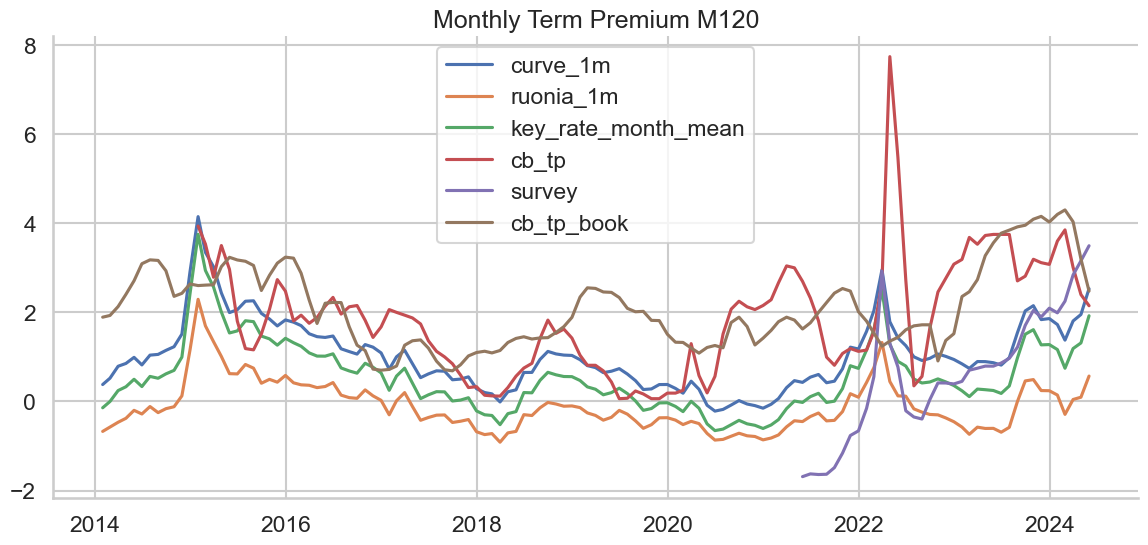

In [ ]:
plt.figure()
plt.title("Monthly Term Premium M120")
for name, result in monthly_results.items():
    plt.plot(result.term_premium_frame.date, result.term_premium_frame['tp_M120'], label=name)
plt.plot( cb_tp, label='cb_tp')
plt.plot(survey.term_premium_frame.date, survey.term_premium_frame['tp_M120'], label="survey")
plt.plot( cb_tp_book, label='cb_tp_book')
plt.legend()
plt.show()